# Modélisation de l'évolution des températures

Ce second notebook prolonge l'analyse exploratoire réalisée précédemment et se concentre sur la **modélisation de l'évolution des anomalies de température globale**.

L'objectif est d'étudier l'apport de différentes approches de **Machine Learning** pour modéliser l'évolution des températures et leur relation avec les émissions de gaz à effet de serre.

Les données de température issues de **LOTI** constituent la principale référence utilisée pour la modélisation. Elles seront notamment mises en relation avec les données d'émissions de **CO₂** préparées précédemment.

Cette approche constitue une application du Machine Learning à nos données et ne vise pas à remplacer les modèles climatiques physiques, qui reposent sur des mécanismes et des variables beaucoup plus complexes.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
import requests

## Chargement des données

La modélisation repose sur les deux jeux de données préparés lors de l'analyse exploratoire :

- **LOTI** : anomalies de température globale et par zones géographiques ;
- **OWID** : données mondiales relatives aux émissions de CO₂ et autres gaz à effet de serre.

Les fichiers nettoyés sont chargés depuis le dossier `data` du projet afin de poursuivre directement l'analyse et la modélisation.

In [3]:
path_loti = "../data/df_zc_loti_clean.csv"
df_loti_base = pd.read_csv(path_loti)
df_loti_base.head()

,Year,Glob,NHem,SHem,N. Extratropics,Tropics,S. Extratropics,Arctic,N. Temperate,N. Subtropics,N. Tropics,S. Tropics,S. Subtropics,S. Temperate,Antarctic
0,1880,-0.18,-0.30,-0.05,-0.40,-0.14,-0.02,-0.81,-0.53,-0.30,-0.16,-0.11,-0.04,0.05,0.69
1,1881,-0.10,-0.20,0.00,-0.37,0.09,-0.07,-0.92,-0.49,-0.21,0.09,0.10,-0.06,-0.07,0.61
2,1882,-0.12,-0.23,-0.01,-0.33,-0.06,0.01,-1.41,-0.30,-0.17,-0.06,-0.05,0.01,0.04,0.64
3,1883,-0.18,-0.29,-0.07,-0.36,-0.17,-0.01,-0.18,-0.57,-0.27,-0.19,-0.16,-0.04,0.07,0.52
4,1884,-0.29,-0.44,-0.15,-0.62,-0.15,-0.14,-1.31,-0.66,-0.48,-0.14,-0.17,-0.19,-0.02,0.67


In [4]:
path_co2 = "../data/co2_world.csv"
df_co2_base = pd.read_csv(path_co2)
df_co2_base.head()

,year,population,gdp,co2,co2_per_capita,co2_including_luc,cumulative_co2,coal_co2,oil_co2,gas_co2,energy_per_capita,primary_energy_consumption,total_ghg,methane,nitrous_oxide,temperature_change_from_co2,temperature_change_from_ghg
0,1880,1.414583e+09,NaN,858.228,0.607,4481.337,18706.131,842.695,15.360,NaN,NaN,NaN,6267.865,1544.166,245.110,0.047,0.064
1,1881,1.423919e+09,NaN,888.173,0.624,4491.630,19594.303,870.726,17.239,NaN,NaN,NaN,6298.316,1561.769,247.807,0.049,0.067
2,1882,1.433851e+09,NaN,938.158,0.654,4621.833,20532.461,918.787,18.936,0.165,NaN,NaN,6448.854,1579.738,250.130,0.051,0.070
3,1883,1.444372e+09,NaN,997.862,0.691,4742.019,21530.324,980.636,16.498,0.381,NaN,NaN,6590.572,1599.377,252.155,0.053,0.073
4,1884,1.455022e+09,NaN,1009.762,0.694,4759.060,22540.088,989.938,18.319,1.172,NaN,NaN,6621.438,1611.351,253.957,0.055,0.076


## Préparation des données pour la modélisation

Pour la suite de l'analyse, nous nous concentrons sur l'évolution de la **température globale de surface** issue du jeu de données LOTI.

Seules les variables nécessaires à la modélisation sont conservées :
- `Year` : l'année d'observation ;
- `Glob` : l'anomalie de température globale.

Les colonnes sont renommées en `year` et `t_surface` afin d'harmoniser leur nomenclature avec les autres données qui seront utilisées par la suite.

La structure du jeu de données ainsi que la présence éventuelle de valeurs manquantes sont ensuite vérifiées avant la modélisation.

In [5]:
df_loti_world = df_loti_base[["Year", "Glob"]].rename(columns={
    "Year": "year",
    "Glob": "t_surface"
})

In [6]:
df_loti_world.info()

<class 'pandas.DataFrame'>
RangeIndex: 146 entries, 0 to 145
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   year       146 non-null    int64  
 1   t_surface  146 non-null    float64
dtypes: float64(1), int64(1)
memory usage: 2.4 KB


In [7]:
df_loti_world.isna().sum()

year         0
t_surface    0
dtype: int64

### Mise en évidence de la tendance de long terme

Afin de mieux visualiser l'évolution de fond des anomalies de température globale, une **moyenne glissante sur 10 ans** est calculée à partir des données LOTI.

Ce lissage permet d'atténuer les variations observées d'une année à l'autre et de faire ressortir plus clairement la **tendance de long terme**.

Cette première observation servira de point de départ aux différentes approches de modélisation étudiées dans la suite du notebook.

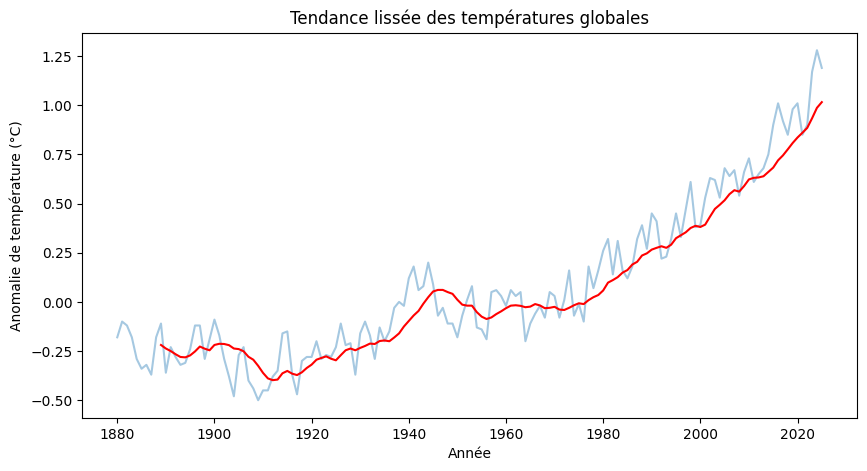

In [8]:
df_loti_world["rolling_mean"] = df_loti_world["t_surface"].rolling(10).mean()

plt.figure(figsize=(10,5))

plt.plot(df_loti_world["year"], df_loti_world["t_surface"], alpha=0.4)
plt.plot(df_loti_world["year"], df_loti_world["rolling_mean"], color="red")

plt.title("Tendance lissée des températures globales")
plt.xlabel("Année")
plt.ylabel("Anomalie de température (°C)")

plt.show()

## Construction du dataset pour la modélisation

Afin de préparer les données pour les modèles de Machine Learning, nous créons une copie du jeu de données LOTI et construisons un **indice temporel `trend`**.

Cet indice représente le nombre d'années écoulées depuis le début de la série :

- `0` correspond à la première année ;
- `1` à l'année suivante ;
- etc.

Cette transformation permet de représenter simplement la **progression du temps** dans les modèles de régression.

In [9]:
df_loti_copy = df_loti_world.copy()

df_loti_copy["trend"] = df_loti_copy["year"] - df_loti_copy["year"].min()

### Ajout des émissions mondiales de CO₂

Les données d'émissions mondiales de **CO₂** sont ensuite associées aux anomalies de température LOTI à partir de l'année commune aux deux jeux de données.

Cette fusion permet d'aligner sur une même chronologie :

- les anomalies de température globale issues de **LOTI** ;
- les émissions mondiales de **CO₂**.

Les observations ne disposant pas de l'ensemble des informations nécessaires sont ensuite retirées afin d'obtenir un dataset exploitable pour la modélisation.

In [10]:
df_co2_world = df_co2_base[["year", "co2"]]

In [11]:
df_loti_copy = df_loti_copy.merge(df_co2_world, on = "year", how = "left")

In [12]:
df_loti_copy = df_loti_copy.dropna(subset=["t_surface", "trend", "co2"])

In [13]:
df_loti_copy.head()

,year,t_surface,rolling_mean,trend,co2
0,1880,-0.18,NaN,0,858.228
1,1881,-0.10,NaN,1,888.173
2,1882,-0.12,NaN,2,938.158
3,1883,-0.18,NaN,3,997.862
4,1884,-0.29,NaN,4,1009.762


| variable     | rôle                |
| ------------ | ------------------- |
| year         | temps brut          |
| t_surface    | cible (température) |
| rolling_mean | tendance lissée     |
| trend        | index temporel      |
| co2          | forçage climatique  |


In [14]:
X = df_loti_copy[["trend", "co2"]]
y = df_loti_copy["t_surface"]

### Définition de la cible et des variables explicatives

Le problème est formulé comme une **régression supervisée**.

**Variable cible (`y`) :**
- `t_surface` : anomalie de température globale que le modèle doit prédire.

**Variables explicatives (`X`) :**
- `trend` : évolution temporelle depuis le début de la période ;
- `co2` : émissions mondiales de CO₂.

Le modèle cherchera ainsi à estimer l'anomalie de température globale à partir de **l'évolution du temps et des émissions de CO₂**.

In [15]:
train = df_loti_copy[df_loti_copy["year"] <= 2005]
test = df_loti_copy[df_loti_copy["year"] > 2005]

X_train = train[["trend", "co2"]]
y_train = train["t_surface"]

X_test = test[["trend", "co2"]]
y_test = test["t_surface"]

### Séparation temporelle des données d'entraînement et de test

Dans le cas d'une série temporelle, les données ne sont pas séparées aléatoirement comme dans un jeu de données classique.

Afin de respecter l'ordre chronologique, le modèle est :

- **entraîné sur les données jusqu'en 2005** ;
- **évalué sur les données postérieures à 2005**.

Cette séparation permet de reproduire une situation de prédiction plus réaliste : le modèle apprend à partir des observations passées afin d'estimer des valeurs sur une période qu'il n'a pas utilisée lors de son entraînement.

Elle évite également d'introduire des informations provenant du futur dans les données d'entraînement.

# ===================================
# MODELE 1 : RANDOM FOREST
# ===================================

In [16]:
from sklearn.ensemble import RandomForestRegressor

In [17]:
rf = RandomForestRegressor(
    n_estimators=300,
    random_state=42
)

rf.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",300
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease o

Le modèle **Random Forest Regressor** est entraîné à partir des variables `trend` et `co2` afin de prédire l'anomalie de température globale `t_surface`.

Cette approche permet de modéliser :

- des **relations non linéaires** ;
- les **interactions entre le CO₂ et l'évolution temporelle** ;
- des **tendances complexes** dans les données.

Le modèle peut ainsi apprendre ces relations **sans imposer au préalable une forme mathématique particulière**.

In [18]:
y_pred = rf.predict(X_test)

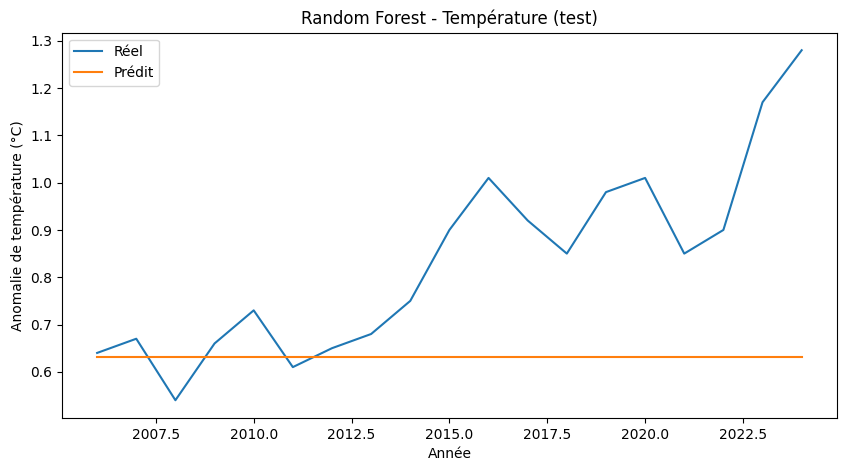

In [31]:
plt.figure(figsize=(10,5))

plt.plot(test["year"], y_test, label="Réel")
plt.plot(test["year"], y_pred, label="Prédit")

plt.legend()
plt.title("Random Forest - Température (test)")
plt.xlabel("Année")
plt.ylabel("Anomalie de température (°C)")

plt.show()

### Résultat du Random Forest

Les prédictions du **Random Forest** restent quasiment constantes sur la période de test, alors que les anomalies de température réelles poursuivent leur augmentation.

Ce comportement met en évidence une limite importante du modèle : le Random Forest est performant pour apprendre des relations complexes **à l'intérieur des données observées**, mais il est peu adapté à **l'extrapolation d'une tendance temporelle au-delà de la période d'entraînement**.

Dans notre cas, il ne parvient donc pas à prolonger la tendance croissante observée dans les températures.

Nous testons ensuite une **régression linéaire**, mieux adaptée à l'extrapolation d'une tendance.

# ===================================
# MODELE 2 : LINEAR REGRESSION
# ===================================

In [20]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

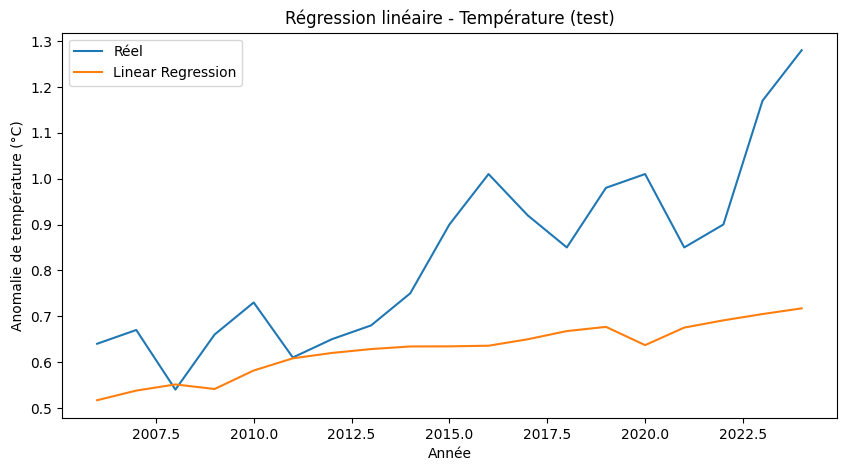

In [21]:
plt.figure(figsize=(10,5))

plt.plot(test["year"], y_test, label="Réel")
plt.plot(test["year"], y_pred_lr, label="Linear Regression")

plt.title("Régression linéaire - Température (test)")
plt.xlabel("Année")
plt.ylabel("Anomalie de température (°C)")

plt.legend()
plt.show()

### Résultat de la régression linéaire

Contrairement au **Random Forest**, la régression linéaire parvient à prolonger la tendance générale à la hausse sur la période de test.

Cependant, les températures prédites restent globalement **inférieures aux valeurs réellement observées**, particulièrement sur les années les plus récentes.

Le modèle capture donc la **tendance générale**, mais sous-estime l'**accélération récente du réchauffement**.

Cette limite suggère qu'une relation strictement linéaire n'est pas suffisante pour représenter toute l'évolution observée.

In [22]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import make_pipeline

In [23]:
poly_model = make_pipeline(
    PolynomialFeatures(degree=2),
    LinearRegression()
)

poly_model.fit(X_train, y_train)

y_pred_poly = poly_model.predict(X_test)

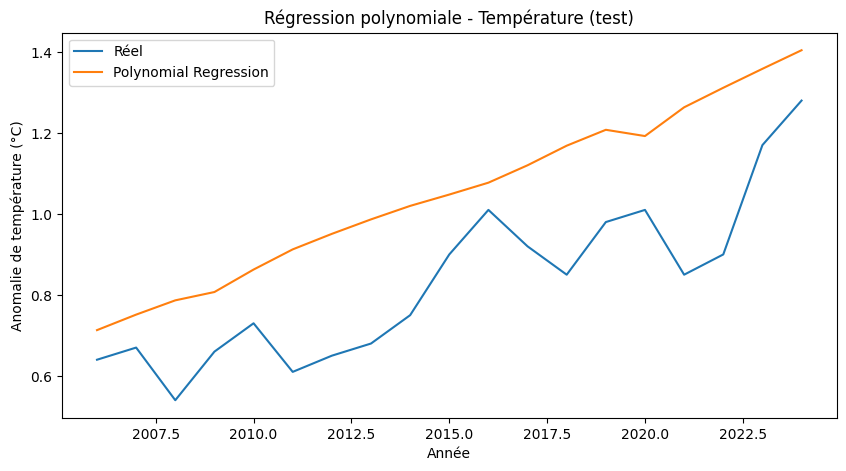

In [24]:
plt.figure(figsize=(10,5))

plt.plot(test["year"], y_test, label="Réel")
plt.plot(test["year"], y_pred_poly, label="Polynomial Regression")

plt.title("Régression polynomiale - Température (test)")
plt.xlabel("Année")
plt.ylabel("Anomalie de température (°C)")

plt.legend()
plt.show()

### Résultat de la régression polynomiale

La **régression polynomiale de degré 2** permet de modéliser une évolution non linéaire et reproduit mieux l'accélération de la tendance que la régression linéaire.

Cependant, sur la période de test, les prédictions restent **globalement supérieures aux températures réellement observées**. Le modèle tend donc ici à **surestimer l'évolution récente**.

Les trois modèles testés présentent ainsi des comportements différents :

- **Random Forest** : extrapole mal au-delà de la période d'entraînement ;
- **Régression linéaire** : reproduit la tendance générale, mais sous-estime la hausse récente ;
- **Régression polynomiale** : capture davantage l'accélération, mais tend à la surestimer.

Ces résultats montrent l'intérêt de comparer plusieurs approches avant de retenir un modèle pour la suite de l'analyse.

# ===================================
# MODELE 3 : META PROPHET
# ===================================

In [25]:
from prophet import Prophet

Importing plotly failed. Interactive plots will not work.


**Prophet** est un modèle spécialement conçu pour l'analyse et la prévision de **séries temporelles**.

Contrairement aux modèles précédents, il prend directement en compte la dimension temporelle des données et cherche notamment à identifier :

- la **tendance générale** de la série ;
- les éventuels **changements de tendance** ;
- les variations autour de cette tendance.

Dans notre cas, les données de température étant annuelles, la saisonnalité présente peu d'intérêt.  
L'objectif principal est donc d'étudier la **tendance de long terme des anomalies de température** et de la prolonger afin d'obtenir une projection.

In [26]:
df_prophet = df_loti_copy[["year", "t_surface"]].copy()

df_prophet["ds"] = pd.to_datetime(df_prophet["year"].astype(str) + "-01-01")
df_prophet["y"] = df_prophet["t_surface"]

df_prophet = df_prophet[["ds", "y"]]

### Préparation des données pour Prophet

Prophet attend un DataFrame contenant deux colonnes spécifiques :

- `ds` : la variable temporelle au format date ;
- `y` : la variable que l'on souhaite modéliser.

La colonne `year` est donc convertie en date et devient `ds`, tandis que l'anomalie de température `t_surface` devient la variable `y`.

Cette structure permet à Prophet de traiter les observations comme une **série temporelle**.

In [27]:
model = Prophet(yearly_seasonality=False)
model.fit(df_prophet)

15:32:57 - cmdstanpy - INFO - Chain [1] start processing
15:32:57 - cmdstanpy - INFO - Chain [1] done processing


### Entraînement du modèle Prophet

Le modèle Prophet est entraîné sur l'ensemble de la série historique des anomalies de température disponibles.

Il apprend principalement **l'évolution de la tendance au cours du temps** et les changements de rythme présents dans la série.

Dans notre cas, les données étant annuelles, la composante saisonnière présente peu d'intérêt : l'objectif est avant tout de modéliser la **tendance de long terme** afin de pouvoir ensuite la prolonger dans le futur.

In [28]:
future = model.make_future_dataframe(periods=25, freq="YE")
forecast = model.predict(future)

À cette étape, nous demandons à Prophet de prolonger automatiquement la série historique de 25 années

Il va ensuite faire la prévision.

Pour chaque date passée ou future, il va produire :

- une prévision centrale,
- une borne basse,
- une borne haute,
- une tendance estimée

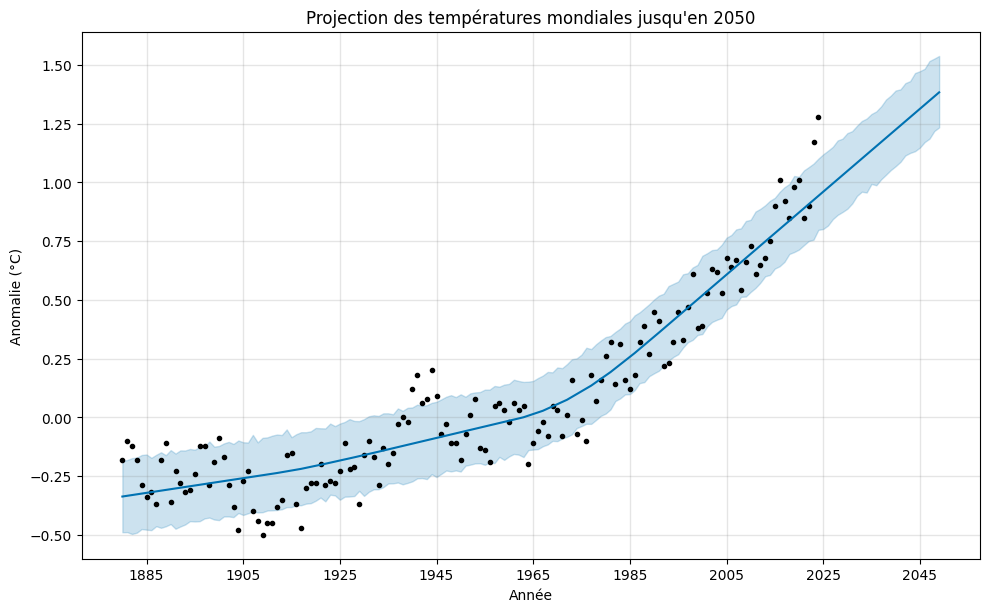

In [29]:
fig = model.plot(forecast)

plt.title("Projection des températures mondiales jusqu'en 2050")
plt.xlabel("Année")
plt.ylabel("Anomalie (°C)")

plt.show()

### Projection des anomalies de température jusqu'en 2050

Le modèle Prophet prolonge la tendance historique observée et estime une poursuite de l'augmentation des anomalies de température jusqu'en 2050.

La projection centrale atteint environ **1,4 °C d'anomalie** à l'horizon 2050.

Sur le graphique :

- les **points noirs** représentent les observations historiques LOTI de la NASA ;
- la **ligne bleue** représente la tendance estimée et sa projection ;
- la **zone bleue claire** représente l'intervalle d'incertitude associé à l'estimation.

Cette projection correspond à une **extrapolation statistique de la tendance observée dans les données historiques**. Elle ne constitue pas un modèle climatique physique et doit donc être interprétée comme une estimation exploratoire.

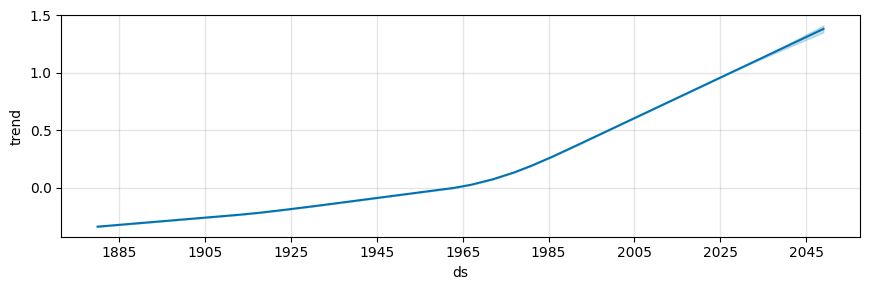

In [30]:
fig2 = model.plot_components(forecast)
plt.show()

### Décomposition du modèle Prophet

La décomposition du modèle permet ici d'isoler la **tendance de fond** estimée par Prophet.

La saisonnalité annuelle ayant été désactivée, le graphique ne conserve que la composante **trend**.

On observe une évolution progressive de la tendance, avec une **accélération plus marquée à partir des dernières décennies**.

## Pourquoi Prophet est-il plus adapté à cette projection ?

Les trois modèles testés présentent des comportements différents :

- **Random Forest** reproduit les relations observées dans les données d'entraînement, mais extrapole difficilement au-delà des valeurs déjà rencontrées ;
- **Régression linéaire** permet d'extrapoler la tendance, mais impose une relation linéaire et représente donc difficilement les changements de rythme ;
- **Prophet** est spécifiquement conçu pour les séries temporelles et permet de modéliser une tendance dont la pente peut évoluer au cours du temps.

Dans notre cas, Prophet apparaît donc **plus adapté à une projection temporelle de long terme**.

### Limites de la projection

Cette modélisation reste toutefois exploratoire. Le modèle Prophet utilisé ici repose uniquement sur l'évolution historique des anomalies de température.

Il ne prend notamment pas directement en compte :

- les futures émissions de **CO₂** ;
- les variations de l'activité océanique ;
- les éruptions volcaniques ;
- les phénomènes climatiques tels que **ENSO** (El Niño – Southern Oscillation).

La projection obtenue ne doit donc pas être interprétée comme une prévision climatique, mais comme une **extrapolation statistique de la tendance historique observée**.